In [4]:
from google.colab import files
uploaded = files.upload()

Saving diabetes_bagging (1).csv to diabetes_bagging (1) (2).csv


   Glucose   BMI  Age  BloodPressure  Insulin  Outcome
0      182  21.1   45             99      100        1
1      131  35.6   67             92      199        1
2      172  19.6   68             68      234        1
3       94  39.7   21            102       83        0
4      186  35.0   20            113       61        1
Index(['Glucose', 'BMI', 'Age', 'BloodPressure', 'Insulin', 'Outcome'], dtype='object')
Decision Tree Accuracy: 1.0
Bagging Accuracy: 1.0


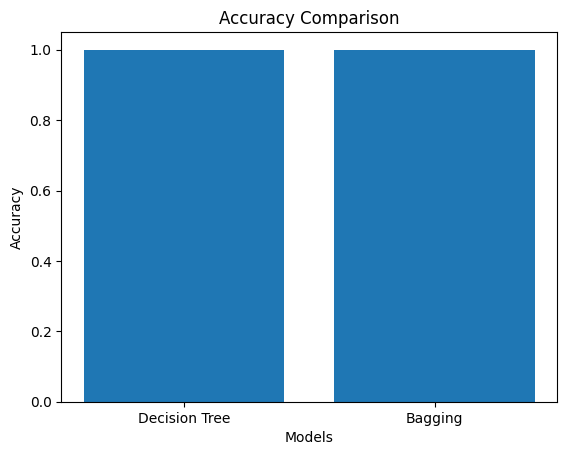

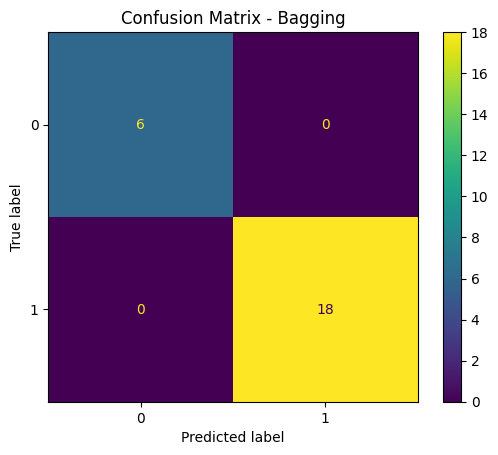

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Read dataset (NO Windows path here)
df = pd.read_csv("diabetes_bagging (1).csv")

# Check data
print(df.head())
print(df.columns)

# Features and target
X = df[['Glucose', 'BMI', 'Age', 'BloodPressure', 'Insulin']]
y = df['Outcome']

# Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Decision Tree
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

from sklearn.metrics import accuracy_score
dt_accuracy = accuracy_score(y_test, y_pred_dt)
print("Decision Tree Accuracy:", dt_accuracy)

# Bagging
from sklearn.ensemble import BaggingClassifier
bag_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=50,
    random_state=42
)

bag_model.fit(X_train, y_train)
y_pred_bag = bag_model.predict(X_test)

bag_accuracy = accuracy_score(y_test, y_pred_bag)
print("Bagging Accuracy:", bag_accuracy)

# Accuracy comparison graph
models = ['Decision Tree', 'Bagging']
accuracies = [dt_accuracy, bag_accuracy]

plt.figure()
plt.bar(models, accuracies)
plt.title("Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.show()

# Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_bag)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - Bagging")
plt.show()